In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

# Path to root of this project, contains lots of modules
import sys
sys.path.insert(0, os.path.abspath('../'))
sys.path.insert(0, os.getcwd())

In [2]:
import math
import random
import numpy
from matplotlib import pyplot
from matplotlib import cm
from sklearn.preprocessing import StandardScaler
from tslearn.clustering import TimeSeriesKMeans
import torch
from torch import nn, optim

In [3]:
from src.learning_shapelets import LearningShapelets

In [6]:
# Import Python NumPy module
import numpy as np
import pandas as pd

# series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\sktime-tutorial-pydata-global-2021\\notebooks\\multivariatetest_data.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)
# series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_train_test_labels.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)
series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_train_test_labelsDWL.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)


print(type(series))
print(series.head(8000))

<class 'pandas.core.frame.DataFrame'>
                 AVE      Range  Label
Date                                  
2023-01-24  2.624485  39.592196    0.0
2023-01-25  2.084280  31.207539    NaN
2023-01-26  0.686775  33.302079    NaN
2023-01-27  4.513830  37.641855    NaN
2023-01-28  3.600000  31.668115    0.0
...              ...        ...    ...
2023-04-09  8.784214  40.866011    NaN
2023-04-10  6.939663  44.209408    1.0
2023-04-11  6.298937  47.486768    NaN
2023-04-12  8.201232  47.769687    NaN
2023-04-13  8.568770  43.894918    NaN

[80 rows x 3 columns]


C:\Users\dema2\AppData\Local\Temp\ipykernel_13148\2549601921.py:5: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\sktime-tutorial-pydata-global-2021\\notebooks\\multivariatetest_data.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)


In [7]:
# new_array1 = series['AVE'].to_numpy() 
# new_array2 = series['Range'].to_numpy() 
new_array1 = series['Displacement'].to_numpy() 
# new_array2 = series['Force'].to_numpy() 

new_array2 = series['Work'].to_numpy() 
combined_array=np.column_stack((new_array1,new_array2))
y = series['Label'].to_numpy() 

In [8]:
print(combined_array)
print(type(combined_array))
print(combined_array.shape)




y = y[~np.isnan(y)]
print(y.shape)
print(y)
print(y.size)





[[ 2.62448472 39.59219637]
 [ 2.08428022 31.20753939]
 [ 0.68677528 33.30207868]
 [ 4.51382958 37.64185485]
 [ 3.6        31.66811538]
 [ 4.56283738 34.30516094]
 [ 0.48382789 35.53954578]
 [ 4.13335627 30.67155916]
 [ 2.04842217 31.75363525]
 [ 3.34481472 31.05006364]
 [ 2.79577566 35.5745468 ]
 [ 2.48106419 33.27901955]
 [ 2.99109804 33.80750773]
 [ 4.16146188 30.38771907]
 [ 1.18063739 30.15944579]
 [ 4.07583516 33.77722609]
 [ 1.28761343 30.79128996]
 [ 1.96525241 36.48604181]
 [ 3.95896365 34.53882187]
 [ 0.60354279 37.16969371]
 [ 2.08466061 39.69796563]
 [ 1.17152659 38.32468823]
 [ 3.92507048 38.35382711]
 [ 4.70204477 34.08139735]
 [ 1.56041354 32.71423976]
 [ 0.18609631 30.88417823]
 [ 2.46725942 37.14159415]
 [ 2.20236571 37.58815759]
 [ 2.75741169 35.44043354]
 [ 2.8737328  38.0602931 ]
 [ 0.43103921 38.42555228]
 [ 2.37541314 37.33979614]
 [ 4.81991594 33.46743227]
 [ 1.04459983 38.56217397]
 [ 2.28711003 37.5036679 ]
 [ 2.76272659 39.62866919]
 [ 3.47517147 31.77986078]
 

In [10]:
X = combined_array.reshape(y.size,2,1)
# X = combined_array.reshape(720,6,5)

print(X)
# np.unique(y)
# y = y.astype('<U1')
np.unique(y)
print(X.shape)
print(y.shape)

ValueError: cannot reshape array of size 160 into shape (20,160,1)

[Text(0, 0.5, 'Scaled distance from midpoint'), Text(0.5, 0, 'Index')]

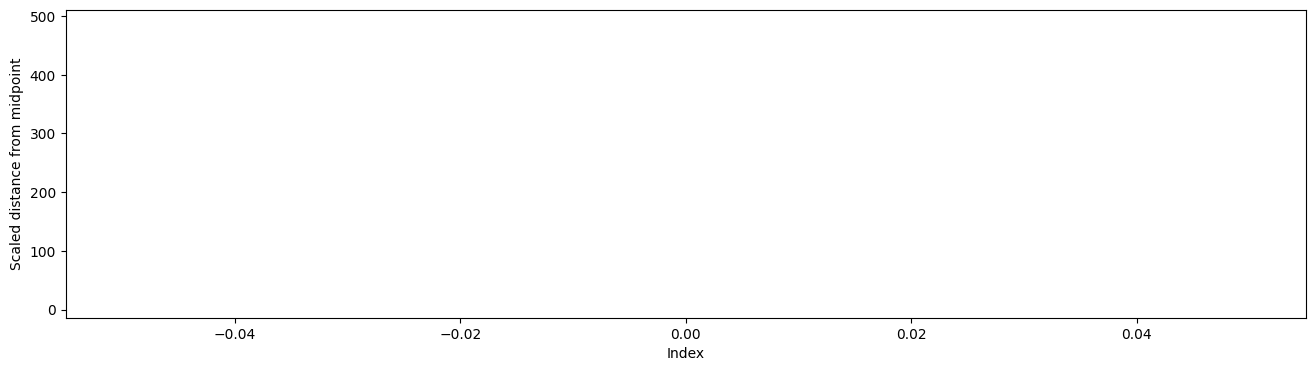

In [117]:
import matplotlib.pyplot as plt

labels, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(1, figsize=plt.figaspect(0.25))

for label in labels:
    ax.plot(X[y == label, 0, :][0], label=f"class {label}")
ax.set(ylabel="Scaled distance from midpoint", xlabel="Index")

In [118]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

print(X_train)
print(X_test)
print(y_train)
print(y_test)

[[[ 368.  ]
  [1012.85]]

 [[ 246.  ]
  [ 614.7 ]]

 [[ 340.  ]
  [ 664.71]]

 ...

 [[ 300.  ]
  [ 611.25]]

 [[ 614.  ]
  [1764.95]]

 [[ 449.  ]
  [ 526.69]]]
[[[374.  ]
  [734.61]]

 [[370.  ]
  [653.29]]

 [[ 95.  ]
  [  0.  ]]

 ...

 [[122.  ]
  [328.33]]

 [[130.  ]
  [321.66]]

 [[312.  ]
  [891.13]]]
[4 5 7 ... 0 3 6]
[7 0 1 ... 2 2 2]


In [119]:
def sample_ts_segments(X, shapelets_size, n_segments=10000):
    """
    Sample time series segments for k-Means.
    """
    n_ts, n_channels, len_ts = X.shape
    samples_i = random.choices(range(n_ts), k=n_segments)
    segments = numpy.empty((n_segments, n_channels, shapelets_size))
    for i, k in enumerate(samples_i):
        s = random.randint(0, len_ts - shapelets_size)
        segments[i] = X[k, :, s:s+shapelets_size]
    return segments

print(X.shape)

(9600, 2, 1)


In [120]:
def get_weights_via_kmeans(X, shapelets_size, num_shapelets, n_segments=10000):
    """
    Get weights via k-Means for a block of shapelets.
    """
    segments = sample_ts_segments(X, shapelets_size, n_segments).transpose(0, 2, 1)
    k_means = TimeSeriesKMeans(n_clusters=num_shapelets, metric="euclidean", max_iter=50).fit(segments)
    clusters = k_means.cluster_centers_.transpose(0, 2, 1)
    return clusters

In [121]:
n_ts, n_channels, len_ts = X_train.shape
loss_func = nn.CrossEntropyLoss()
num_classes = len(set(y_train))
# learn 2 shapelets of length 130
shapelets_size_and_len = {1: 1000}
dist_measure = "euclidean"
lr = 1e-2
wd = 1e-3
epsilon = 1e-7



In [122]:
learning_shapelets = LearningShapelets(shapelets_size_and_len=shapelets_size_and_len,
                                       in_channels=n_channels,
                                       num_classes=num_classes,
                                       loss_func=loss_func,
                                       to_cuda=False,
                                       verbose=1,
                                       dist_measure=dist_measure)

In [123]:
for i, (shapelets_size, num_shapelets) in enumerate(shapelets_size_and_len.items()):
    weights_block = get_weights_via_kmeans(X_train, shapelets_size, num_shapelets)
    learning_shapelets.set_shapelet_weights_of_block(i, weights_block)

In [124]:
optimizer = optim.Adam(learning_shapelets.model.parameters(), lr=lr, weight_decay=wd, eps=epsilon)
learning_shapelets.set_optimizer(optimizer)

In [125]:
losses = learning_shapelets.fit(X_train, y_train, epochs=2000, batch_size=256, shuffle=False, drop_last=False)

Loss: 509.96563720703125: 100%|██████████| 2000/2000 [39:17<00:00,  1.18s/it]


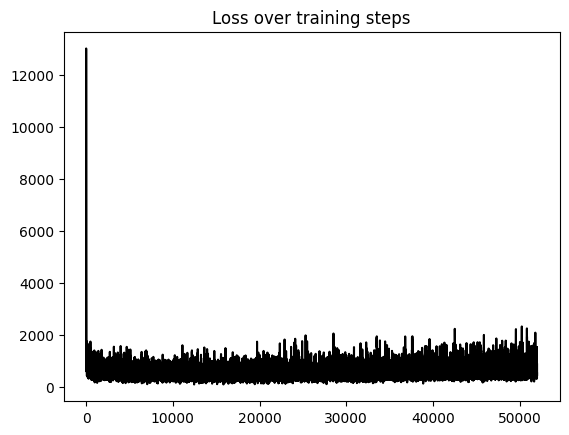

In [126]:
pyplot.plot(losses, color='black')
pyplot.title("Loss over training steps")
pyplot.show()

In [127]:
def eval_accuracy(model, X, Y):
    predictions = model.predict(X)
    if len(predictions.shape) == 2:
        predictions = predictions.argmax(axis=1)
        print(predictions)
    print(f"Accuracy: {(predictions == Y).sum() / Y.size}")

In [128]:
eval_accuracy(learning_shapelets, X_test, y_test)
# print(X_test)
print(y_test)



[7 7 1 ... 2 2 3]
Accuracy: 0.5416666666666666
[7 0 1 ... 2 2 2]


In [129]:
test = np.array([[[ 2,  3,  4,  4]]])
# print(type(test))
test_pred = learning_shapelets.predict(test)
print(test_pred.argmax())


4
